In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The mean of XCO2 before correction is: 405.4693846153845


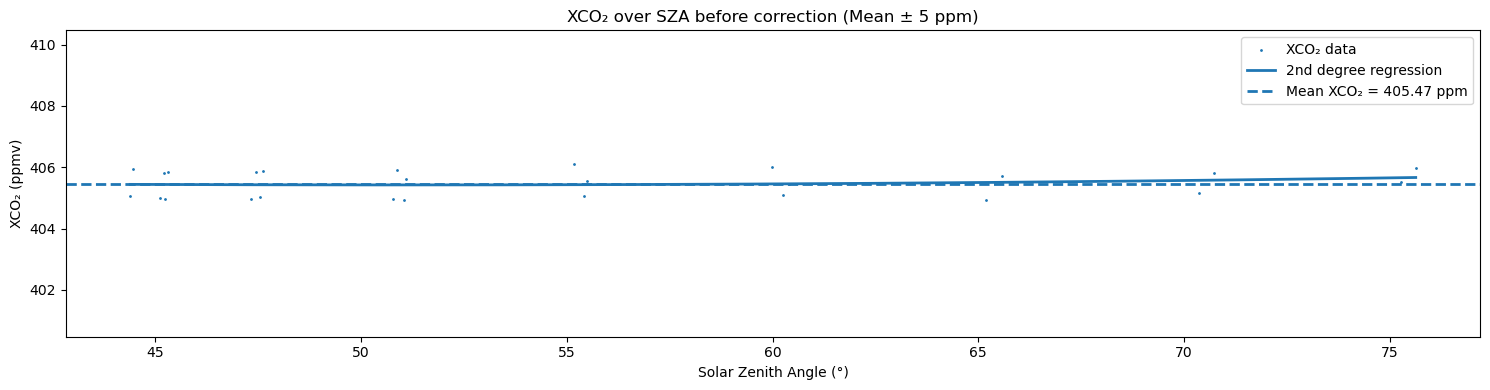

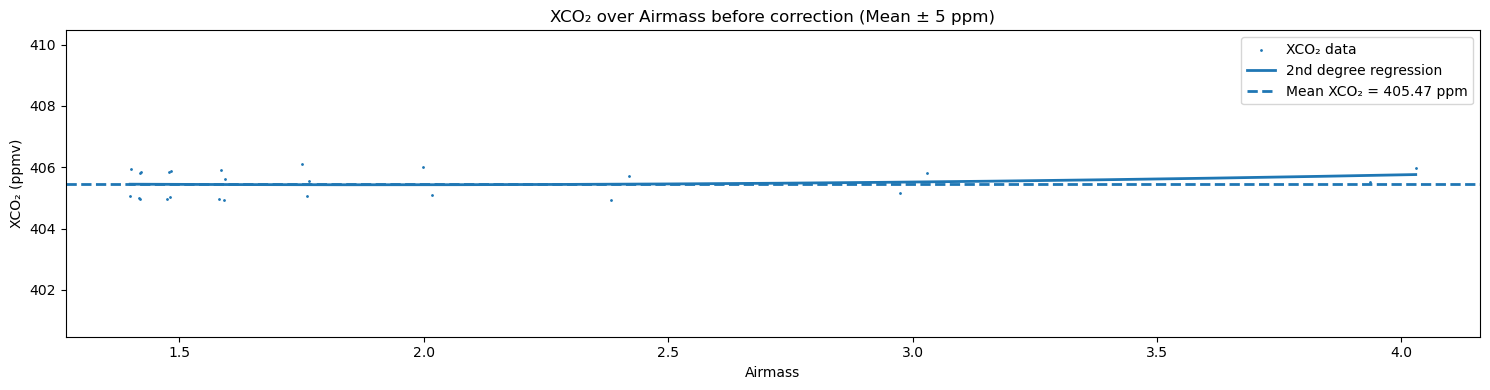

In [3]:
# Read Data
df = pd.read_csv(
    r"D:\Desktop\Hiwi\ASF\proffastpylot\example\results\Sodankyla_SN039_170608-170609\comb_invparms_Sodankyla_SN039_170608-170609.csv",
    skipinitialspace=True
)

df_XCO2_small = df[["JulianDate", "appSZA", "XCO2"]]

# Filter for SZA ≤ 86
df_filt = df_XCO2_small[df_XCO2_small["appSZA"] <= 86].copy()

# Compute airmass
df_filt["airmass"] = 1 / np.cos(np.deg2rad(df_filt["appSZA"]))

# Mean XCO2 before correction
mean_XCO2 = df_filt["XCO2"].mean()
print("The mean of XCO2 before correction is:", mean_XCO2)


# =========================
# XCO2 VS SZA Plot
# =========================

x_sza = df_filt["appSZA"]
y = df_filt["XCO2"]

# 2nd degree polynomial fit
coeff_sza = np.polyfit(x_sza, y, deg=2)
poly_sza = np.poly1d(coeff_sza)

# Smooth x-values for drawing the regression line
x_sza_fit = np.linspace(x_sza.min(), x_sza.max(), 500)
y_sza_fit = poly_sza(x_sza_fit)

fig, ax = plt.subplots(figsize=(15, 4))

ax.scatter(x_sza, y, s=1, label="XCO₂ data")

# Regression line
ax.plot(
    x_sza_fit,
    y_sza_fit,
    linewidth=2,
    label="2nd degree regression"
)

# Mean line
ax.axhline(
    mean_XCO2,
    linestyle="--",
    linewidth=2,
    label=f"Mean XCO₂ = {mean_XCO2:.2f} ppm"
)

ax.set_xlabel("Solar Zenith Angle (°)")
ax.set_ylabel("XCO₂ (ppmv)")
ax.set_title("XCO₂ over SZA before correction (Mean ± 5 ppm)")
ax.set_ylim(mean_XCO2 - 5, mean_XCO2 + 5)
ax.legend()
plt.tight_layout()
plt.show()


# =========================
# XCO2 VS Airmass Plot
# =========================

x_airmass = df_filt["airmass"]

# 2nd degree polynomial fit
coeff_airmass = np.polyfit(x_airmass, y, deg=2)
poly_airmass = np.poly1d(coeff_airmass)

# Smooth x-values for drawing the regression line
x_airmass_fit = np.linspace(x_airmass.min(), x_airmass.max(), 500)
y_airmass_fit = poly_airmass(x_airmass_fit)

fig, ax = plt.subplots(figsize=(15, 4))

ax.scatter(x_airmass, y, s=1, label="XCO₂ data")

# Regression line
ax.plot(
    x_airmass_fit,
    y_airmass_fit,
    linewidth=2,
    label="2nd degree regression"
)

# Mean line
ax.axhline(
    mean_XCO2,
    linestyle="--",
    linewidth=2,
    label=f"Mean XCO₂ = {mean_XCO2:.2f} ppm"
)

ax.set_xlabel("Airmass")
ax.set_ylabel("XCO₂ (ppmv)")
ax.set_title("XCO₂ over Airmass before correction (Mean ± 5 ppm)")
ax.set_ylim(mean_XCO2 - 5, mean_XCO2 + 5)
ax.legend()
plt.tight_layout()
plt.show()

In [1]:
import sys
sys.path.append("D:/Desktop/Hiwi/ASF/AirMass_Dependence_Task/Modules")

from analyze_em27_dataset import analyze_em27_dataset
analyze_em27_dataset?

Signature:
analyze_em27_dataset(
    filepath,
    filepath_corr_XCO2,
    filepath_corr_XCH4,
    station,
    date,
    filepath_corr_XAIR=None,
    save_dir=None,
    ylim_XAIR_before=0.01,
    ylim_XCO2_before=5,
    ylim_XCH4_before=0.03,
    ylim_XAIR_after=0.01,
    ylim_XCO2_after=2,
    ylim_XCH4_after=0.01,
    start=None,
    end=None,
    fit_summary_file=None,
    Random_values=False,
    save_XAIR=False,
)
Docstring: <no docstring>
File:      d:\desktop\hiwi\asf\airmass_dependence_task\modules\analyze_em27_dataset.py
Type:      function

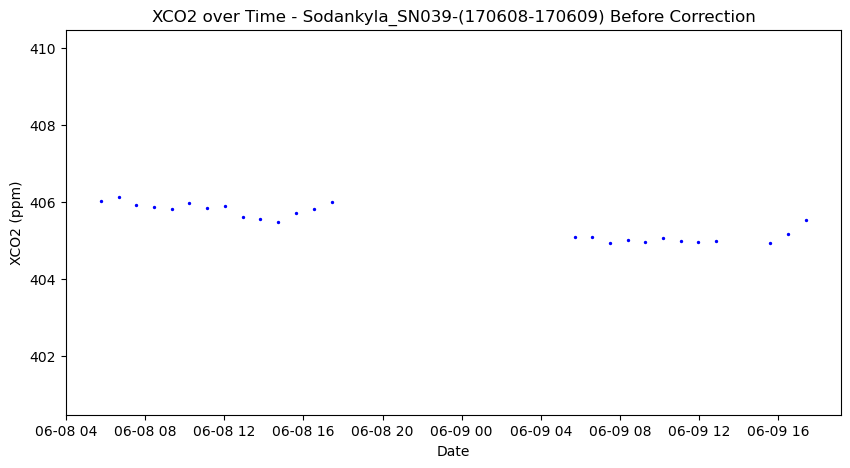

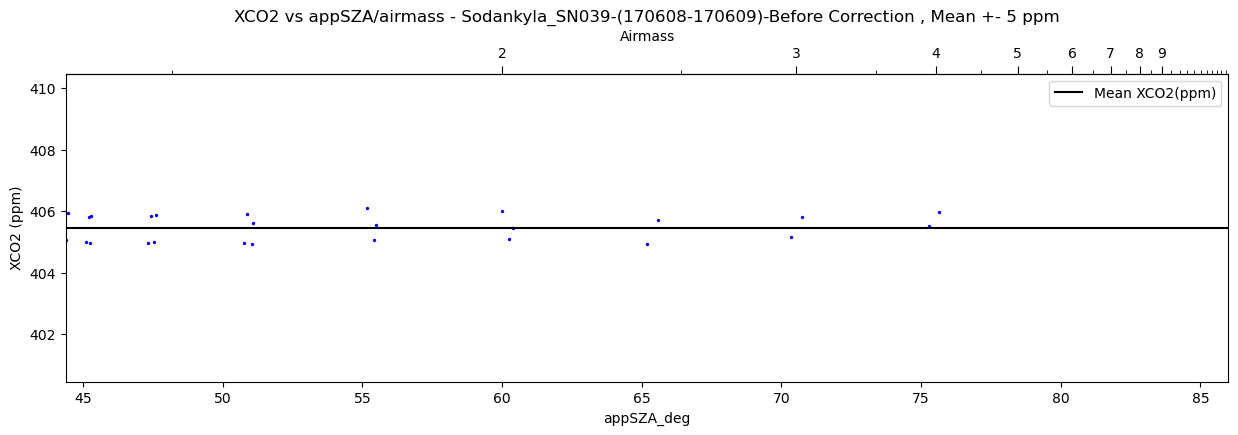

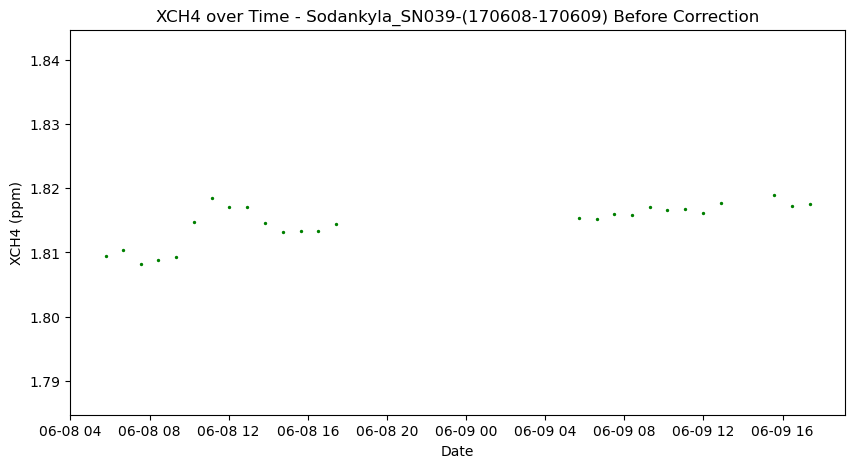

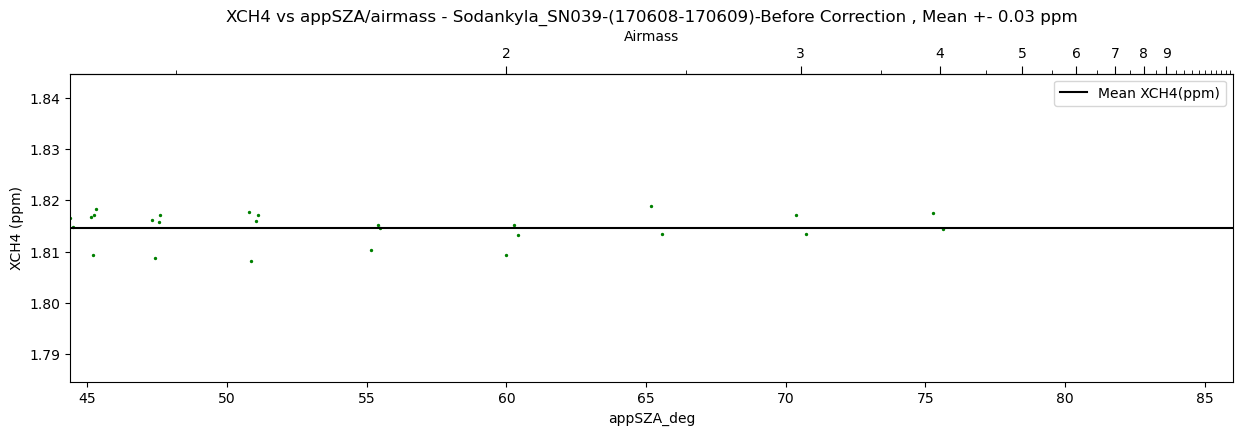

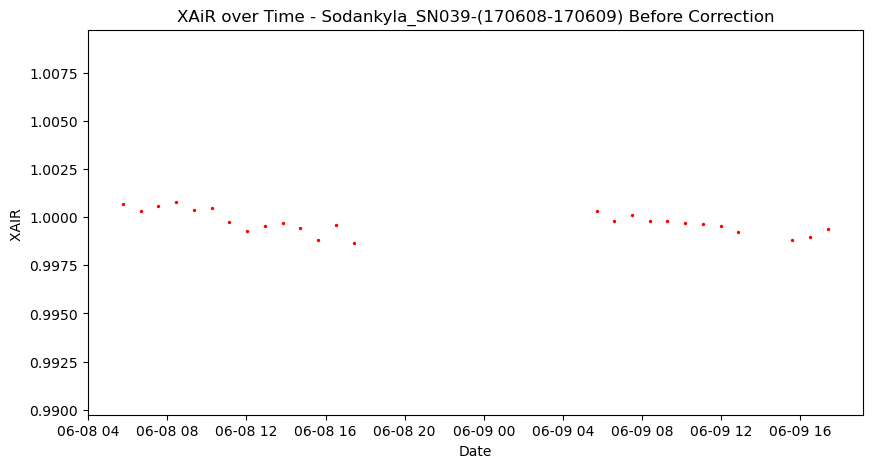

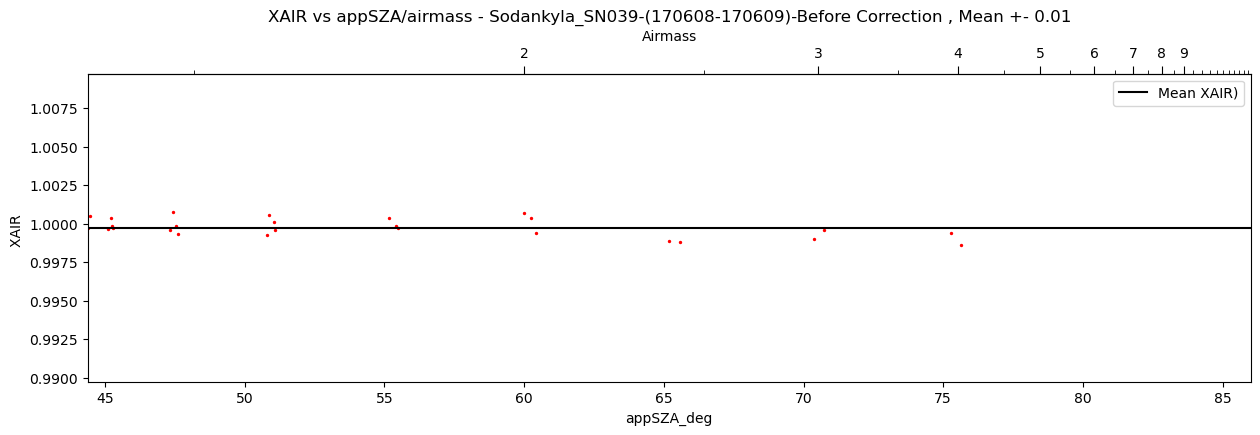

ValueError: Invalid file path or buffer object type: <class 'NoneType'>

In [2]:
data = analyze_em27_dataset(filepath=r"D:\Desktop\Hiwi\ASF\proffastpylot\example\results\Sodankyla_SN039_170608-170609\comb_invparms_Sodankyla_SN039_170608-170609.csv",
                            filepath_corr_XCO2=None,
                            filepath_corr_XCH4=None,
                            station ='Sodankyla_SN039',
                            date='170608-170609')